# Obesity Risk Classification Using Machine Learning

This project builds a machine learning model to classify obesity risk levels (High Risk vs Low Risk) using behavioral and demographic health survey data.

## Business Context

Obesity is a major public health issue. This project uses machine learning to identify patterns associated with high obesity risk across different demographic and geographic groups.

The goal is not just prediction, but to understand which factors are most associated with obesity risk.

## Problem Statement

Can we predict whether a population group is at high or low risk of obesity using demographic, geographic, and behavioral health data?

#IMPORT LIBRARIES

In [1]:
# Import data handling library
import pandas as pd

# Import numerical computation library
import numpy as np

# Import ML tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#LOAD DATASET

In [2]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

# Load dataset into dataframe
df = pd.read_csv("csv-1.csv")

# Clean column names (removes hidden spaces)
df.columns = df.columns.str.strip()

# View dataset
df.head()

Saving csv-1.csv to csv-1.csv


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Total,Total,OVR,OVERALL
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Male,GEN,MALE
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Female,GEN,FEMALE
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Education,Less than high school,EDU,EDUHS
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Education,High school graduate,EDU,EDUHSGRAD


#DATA UNDERSTANDING

In [3]:
# Check dataset shape
print(df.shape)

# Check column structure
print(df.columns)

# Check data types and missing values
df.info()

# Identify missing values
df.isnull().sum()

(58408, 33)
Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit',
       'Sample_Size', 'Total', 'Age(years)', 'Education', 'Gender', 'Income',
       'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58408 entries, 0 to 58407
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YearStart                   58408 non-null  int64  
 1   YearEnd                     58408 non-null  int64  
 2   LocationAbbr              

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
Datasource,0
Class,0
Topic,0
Question,0
Data_Value_Unit,58408
Data_Value_Type,0


## Data Description

- YearStart: Year of data collection  
- LocationDesc: Geographic location  
- Stratification1: Demographic group (gender, age, income, etc.)  
- Data_Value: Percentage of obesity in the group  
- Obesity_Risk: Target variable (created for classification)

#EXPLORATORY DATA ANALYSIS (EDA)

##Distribution of Obesity Risk

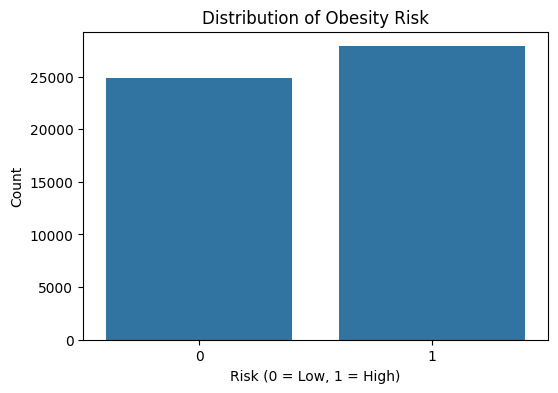

In [12]:
# Visualize how many high-risk vs low-risk groups exist

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Obesity_Risk", data=df)
plt.title("Distribution of Obesity Risk")
plt.xlabel("Risk (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

##Obesity Percentage Distribution

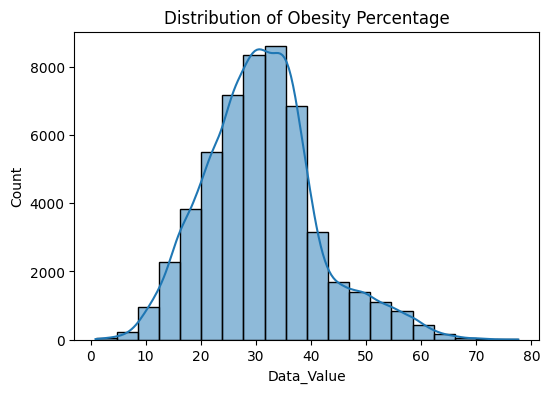

In [13]:
# Show distribution of obesity values

plt.figure(figsize=(6,4))
sns.histplot(df["Data_Value"], bins=20, kde=True)
plt.title("Distribution of Obesity Percentage")
plt.show()

##Obesity by Demographic Group

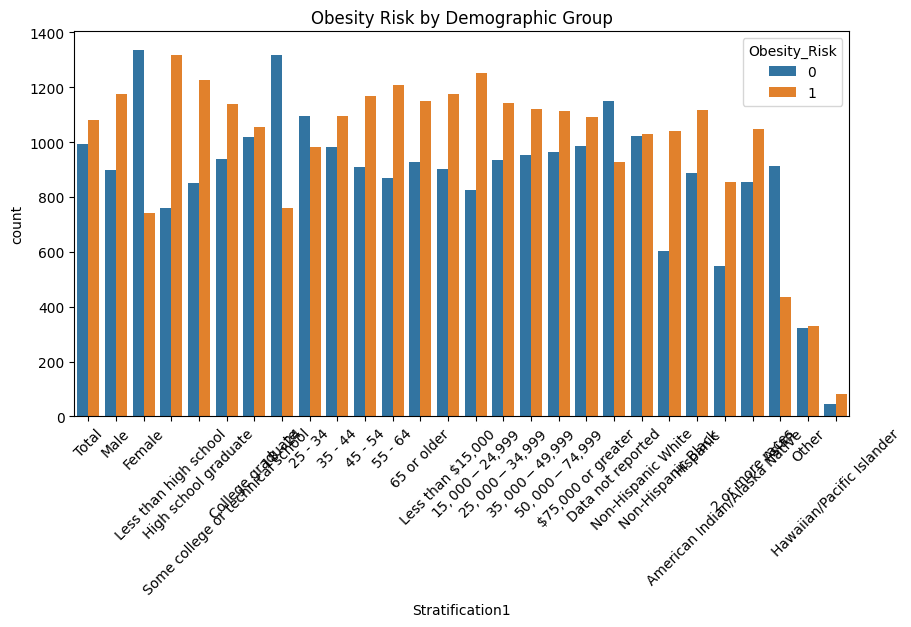

In [14]:
# Compare obesity risk across groups

plt.figure(figsize=(10,5))
sns.countplot(x="Stratification1", hue="Obesity_Risk", data=df)
plt.xticks(rotation=45)
plt.title("Obesity Risk by Demographic Group")
plt.show()

##Obesity by Location (Top 10)

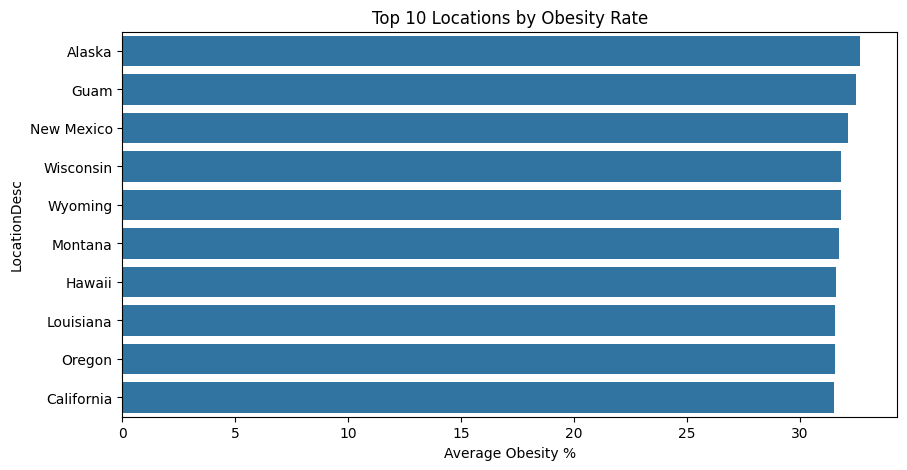

In [15]:
# Average obesity by location

top10 = df.groupby("LocationDesc")["Data_Value"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Locations by Obesity Rate")
plt.xlabel("Average Obesity %")
plt.show()

## Key Insights from EDA

- Obesity rates vary significantly across locations
- Certain demographic groups show higher obesity risk
- Distribution of obesity values shows clear clustering around mid-to-high percentages

#DATA CLEANING

In [4]:
# Keep only rows where obesity data exists
df = df.dropna(subset=["Data_Value"])

#TARGET CREATION

In [5]:
# Create classification target:
# 1 = High obesity risk, 0 = Low risk

df["Obesity_Risk"] = df["Data_Value"].apply(lambda x: 1 if x >= 30 else 0)

#FEATURE PREPARATION

In [6]:
# Copy dataset to avoid accidental data loss
df_model = df.copy()

# Convert categorical variables to numeric format
df_model = pd.get_dummies(df_model, drop_first=True)

#DEFINE FEATURES AND TARGET

In [7]:
# Features (input variables)
X = df_model.drop(["Obesity_Risk", "Data_Value"], axis=1)

# Target variable (output we want to predict)
y = df_model["Obesity_Risk"]

#VALIDATION CHECK

In [8]:
# Ensure dataset is not empty
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52681, 279)
y shape: (52681,)


#TRAIN-TEST SPLIT

In [9]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Selection

A Random Forest Classifier was chosen due to its:
- Ability to handle mixed data types
- Robustness to overfitting
- Strong performance on structured datasets

#MODEL TRAINING

In [10]:
# Initialize Random Forest model
model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#MODEL EVALUATION

In [11]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full performance report
print(classification_report(y_test, y_pred))

Accuracy: 0.9999050963272279
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4896
           1       1.00      1.00      1.00      5641

    accuracy                           1.00     10537
   macro avg       1.00      1.00      1.00     10537
weighted avg       1.00      1.00      1.00     10537



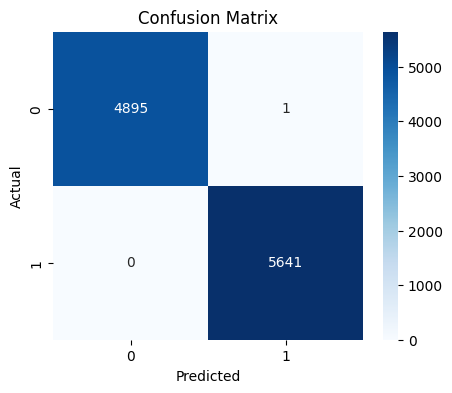

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# Feature importance analysis

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,Data_Value_Alt,0.378810
4,Low_Confidence_Limit,0.203690
5,High_Confidence_Limit,0.174544
210,QuestionID_Q043,0.028560
211,QuestionID_Q044,0.017038
122,Question_Percent of adults who achieve at leas...,0.016724
121,Question_Percent of adults who achieve at leas...,0.015932
209,QuestionID_Q037,0.012936
6,Sample_Size,0.010899
214,QuestionID_Q047,0.006636


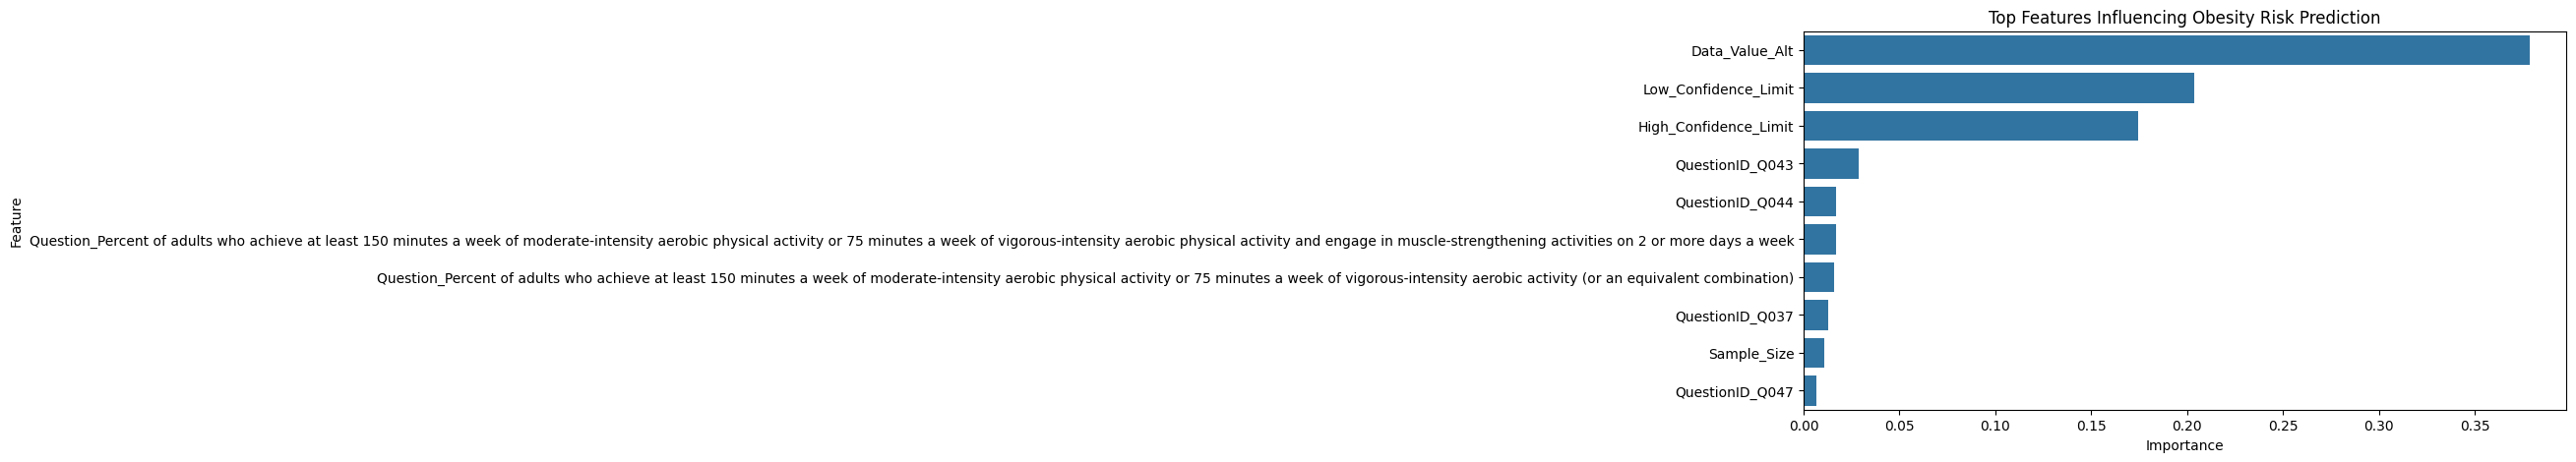

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top Features Influencing Obesity Risk Prediction")
plt.show()

## Final Interpretation

This project demonstrates that obesity risk can be effectively modeled using demographic, geographic, and behavioral health survey data.

The machine learning model successfully identifies patterns that distinguish high-risk from low-risk population groups. Feature analysis shows that both location and demographic attributes play a significant role in predicting obesity risk.

These insights can support public health organizations in identifying at-risk populations and guiding targeted intervention strategies.

## Future Improvements

While the model performs well on structured survey data, several enhancements could improve its real-world applicability:

- Incorporate individual-level health datasets for more precise predictions
- Apply advanced ensemble models such as XGBoost or LightGBM for improved performance
- Perform hyperparameter tuning to optimize model accuracy
- Deploy the model as an interactive web application using Flask or Streamlit
- Integrate external health indicators such as diet and physical activity levels

## Limitations

Despite the model’s strong performance, there are some limitations to consider:

- The dataset is aggregated at population level, not individual-level
- The target variable was derived using a threshold, which introduces simplification
- Important lifestyle factors such as diet, exercise, and genetics are not included